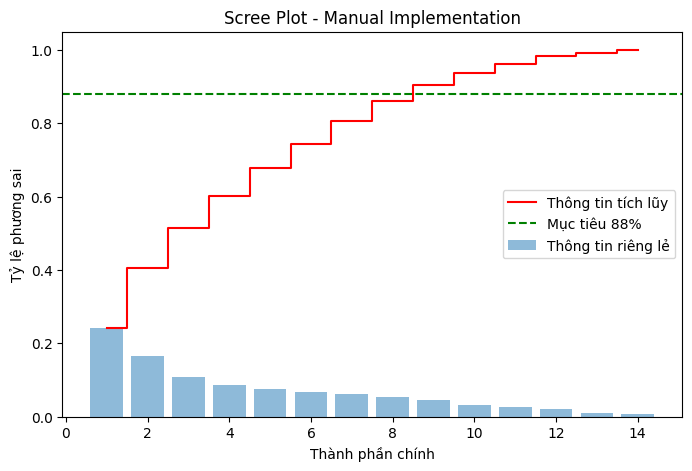

Nhận xét: Sử dụng PCA thủ công giúp giảm từ 14 biến xuống 2 biến.
Lượng thông tin giữ lại được: 40.61%


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Đọc và gộp dữ liệu Train (2022-2024) giống bản Library
files = ['../data_raw/2022.csv', '../data_raw/2023.csv', '../data_raw/2024.csv']
df_list = [pd.read_csv(f) for f in files]
df_train = pd.concat(df_list, axis=0, ignore_index=True)

# 2. Tiền xử lý: Chỉ lấy cột số và xóa dòng trống (NaN)
X = df_train.select_dtypes(include=[np.number]).dropna()
X_values = X.values # Chuyển sang dạng mảng Numpy để tính toán không bị lỗi index

# 3. Chuẩn hóa thủ công (Standardization)
# Công thức: (X - mean) / std
X_mean = np.mean(X_values, axis=0)
X_std = np.std(X_values, axis=0)
X_scaled = (X_values - X_mean) / X_std

# 4. Tính ma trận Hiệp phương sai (Covariance Matrix)
# Công thức: cov = (X^T * X) / (n-1)
features_T = X_scaled.T
cov_matrix = np.cov(features_T)

# 5. Tính Trị riêng (Eigenvalues) và Vectơ riêng (Eigenvectors)
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

# 6. Sắp xếp Trị riêng giảm dần để tìm thành phần chính
sorted_index = np.argsort(eigen_values)[::-1]
sorted_eigenvalue = eigen_values[sorted_index]
sorted_eigenvectors = eigen_vectors[:, sorted_index]

# 7. Chọn 2 thành phần chính (n_components=2)
n_components = 2
eigenvector_subset = sorted_eigenvectors[:, 0:n_components]

# 8. Chiếu dữ liệu vào không gian mới (Giảm chiều)
X_reduced = np.dot(X_scaled, eigenvector_subset)

# 9. Tính toán % thông tin giữ lại cho biểu đồ Scree Plot
exp_var = sorted_eigenvalue / np.sum(sorted_eigenvalue)
cum_var = np.cumsum(exp_var)

# 10. Vẽ biểu đồ Scree Plot (Yêu cầu kỹ thuật)
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(exp_var) + 1), exp_var, alpha=0.5, align='center', label='Thông tin riêng lẻ')
plt.step(range(1, len(cum_var) + 1), cum_var, where='mid', label='Thông tin tích lũy', color='red')
plt.axhline(y=0.88, color='g', linestyle='--', label='Mục tiêu 88%')
plt.ylabel('Tỷ lệ phương sai')
plt.xlabel('Thành phần chính')
plt.title('Scree Plot - Manual Implementation')
plt.legend()
plt.show()

# In kết quả nhận xét
info_2_comp = cum_var[1] * 100
print(f"Nhận xét: Sử dụng PCA thủ công giúp giảm từ {X.shape[1]} biến xuống 2 biến.")
print(f"Lượng thông tin giữ lại được: {info_2_comp:.2f}%")

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 11. StandardScaler trước khi clustering
scaler = StandardScaler()
X_scaled_std = scaler.fit_transform(X)

# 12. Elbow method để tìm số cluster tối ưu
inertia = []
ks = list(range(1, 11))
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled_std)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(ks, inertia, marker='o')
plt.xticks(ks)
plt.xlabel('Số lượng cluster k')
plt.ylabel('Inertia (SSE)')
plt.title('Elbow Method cho K-Means')
plt.grid(alpha=0.3)
plt.show()

# Chọn k tối ưu từ elbow plot
k_opt = 3
km = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled_std)

# 13. Visualize cluster trên PCA 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_std)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=25, alpha=0.7)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title(f'K-Means clusters visualized on PCA 2D (k={k_opt})')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.grid(alpha=0.3)
plt.show()

# 14. Phân tích đặc trưng từng cluster
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(km.cluster_centers_),
    columns=X.columns
)
cluster_centers.index.name = 'cluster'
cluster_centers['cluster'] = range(k_opt)
cluster_centers = cluster_centers.set_index('cluster')
print('Cluster centroids (original scale):')
print(cluster_centers.round(2))

# Gắn nhãn cluster vào bản gốc để phân tích theo mùa / giờ
clustered_df = df_train.loc[X.index].copy()
clustered_df['cluster'] = labels

if 'date' in clustered_df.columns:
    clustered_df['date'] = pd.to_datetime(clustered_df['date'])
    clustered_df['hour'] = clustered_df['date'].dt.hour
    clustered_df['month'] = clustered_df['date'].dt.month

if 'season' in clustered_df.columns:
    clustered_df['season_name'] = clustered_df['season']
elif 'month' in clustered_df.columns:
    clustered_df['season_name'] = pd.cut(
        clustered_df['month'],
        bins=[0, 3, 6, 9, 12],
        labels=['Winter', 'Spring', 'Summer', 'Autumn'],
        right=True
    )

print('\nCluster size:')
print(clustered_df['cluster'].value_counts().sort_index())

if 'aqi' in clustered_df.columns:
    print('\nMean AQI by cluster:')
    print(clustered_df.groupby('cluster')['aqi'].mean().round(2))

if 'season_name' in clustered_df.columns:
    print('\nCluster distribution by season:')
    print(clustered_df.groupby(['cluster', 'season_name']).size().unstack(fill_value=0))

if 'hour' in clustered_df.columns:
    print('\nCluster distribution by hour:')
    hour_counts = clustered_df.groupby(['cluster', 'hour']).size().unstack(fill_value=0)
    print(hour_counts)
    top_hours = hour_counts.idxmax(axis=1)
    print('\nHour with most members in each cluster:')
    print(top_hours)

# Nếu có AQI, đánh giá cluster nào ô nhiễm nhất
if 'aqi' in clustered_df.columns:
    aqi_cluster = clustered_df.groupby('cluster')['aqi'].mean().sort_values(ascending=False)
    print('\nClusters ranked by mean AQI:')
    print(aqi_cluster.round(2))
